# Plant Disease Detection - Baseline Training
YOLOv8 Classification Model for 15 Plant Disease Classes (No Augmentation)

## Dataset: PlantVillage
- Total Images: 41,272
- Classes: 15
- Plants: Tomatoes (10), Potatoes (3), Peppers (2)

In [1]:
# Import required libraries
from ultralytics import YOLO
import torch
import os
from pathlib import Path

# Check CUDA availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Ti


In [2]:
# Define paths
DATA_DIR = Path('datasets/plantvillage/train/PlantVillage')
PROJECT_NAME = 'runs/classify'
RUN_NAME = 'plant_disease_original'

# Verify dataset structure
print(f"\nDataset directory: {DATA_DIR}")
print(f"Dataset exists: {DATA_DIR.exists()}")

if DATA_DIR.exists():
    classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
    print(f"\nTotal classes found: {len(classes)}")
    print("\nClasses:")
    for i, cls in enumerate(classes, 1):
        num_images = len(list((DATA_DIR / cls).glob('*.jpg')) + list((DATA_DIR / cls).glob('*.JPG')))
        print(f"{i:2d}. {cls:50s} - {num_images:5d} images")


Dataset directory: datasets\plantvillage\train\PlantVillage
Dataset exists: True

Total classes found: 15

Classes:
 1. Pepper__bell___Bacterial_spot                      -  1994 images
 2. Pepper__bell___healthy                             -  2954 images
 3. Potato___Early_blight                              -  2000 images
 4. Potato___Late_blight                               -  2000 images
 5. Potato___healthy                                   -   304 images
 6. Tomato_Bacterial_spot                              -  4254 images
 7. Tomato_Early_blight                                -  2000 images
 8. Tomato_Late_blight                                 -  3816 images
 9. Tomato_Leaf_Mold                                   -  1904 images
10. Tomato_Septoria_leaf_spot                          -  3542 images
11. Tomato_Spider_mites_Two_spotted_spider_mite        -  3352 images
12. Tomato__Target_Spot                                -  2808 images
13. Tomato__Tomato_YellowLeaf__Curl_Virus  

In [3]:
# Expected 15 classes
EXPECTED_CLASSES = [
    'Pepper__bell___Bacterial_spot',
    'Pepper__bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

print(f"Expected classes: {len(EXPECTED_CLASSES)}")
print(f"\nVerifying all expected classes exist...")

missing_classes = []
extra_classes = []

for expected in EXPECTED_CLASSES:
    if expected not in classes:
        missing_classes.append(expected)

for found in classes:
    if found not in EXPECTED_CLASSES:
        extra_classes.append(found)

if missing_classes:
    print(f"\nWARNING - Missing classes: {missing_classes}")
if extra_classes:
    print(f"\nWARNING - Extra classes (should be removed): {extra_classes}")
if not missing_classes and not extra_classes:
    print("\nSUCCESS: All 15 classes verified!")

Expected classes: 15

Verifying all expected classes exist...

SUCCESS: All 15 classes verified!


In [4]:
# Load YOLOv8 nano classification model
model = YOLO('yolov8n-cls.pt')

print("\nModel loaded successfully!")
print(f"Model type: Classification")
print(f"Model size: Nano")


Model loaded successfully!
Model type: Classification
Model size: Nano


In [ ]:
# Training configuration - NO AUGMENTATION
results = model.train(
    data=str(DATA_DIR),
    epochs=50,
    imgsz=224,
    batch=32,
    device=0 if torch.cuda.is_available() else 'cpu',
    project=PROJECT_NAME,
    name=RUN_NAME,
    exist_ok=True,
    patience=10,
    save=True,
    save_period=5,
    
    # NO DATA AUGMENTATION
    hsv_h=0.0,      # No hue augmentation
    hsv_s=0.0,      # No saturation augmentation
    hsv_v=0.0,      # No value/brightness augmentation
    degrees=0.0,    # No rotation
    translate=0.0,  # No translation
    scale=0.0,      # No scaling
    shear=0.0,      # No shearing
    perspective=0.0, # No perspective
    flipud=0.0,     # No vertical flip
    fliplr=0.0,     # No horizontal flip
    mosaic=0.0,     # No mosaic augmentation
    mixup=0.0,      # No mixup augmentation
    
    # Optimizer settings
    optimizer='Adam',
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    
    # Logging
    verbose=True,
    plots=True
)

print("\n" + "="*50)
print("TRAINING COMPLETE - ORIGINAL (NO AUGMENTATION)")
print("="*50)


Training Results:
Best weights saved to: runs\classify\plant_disease_original\weights\best.pt
Last weights saved to: runs\classify\plant_disease_original\weights\last.pt

Confusion Matrix (Normalized):


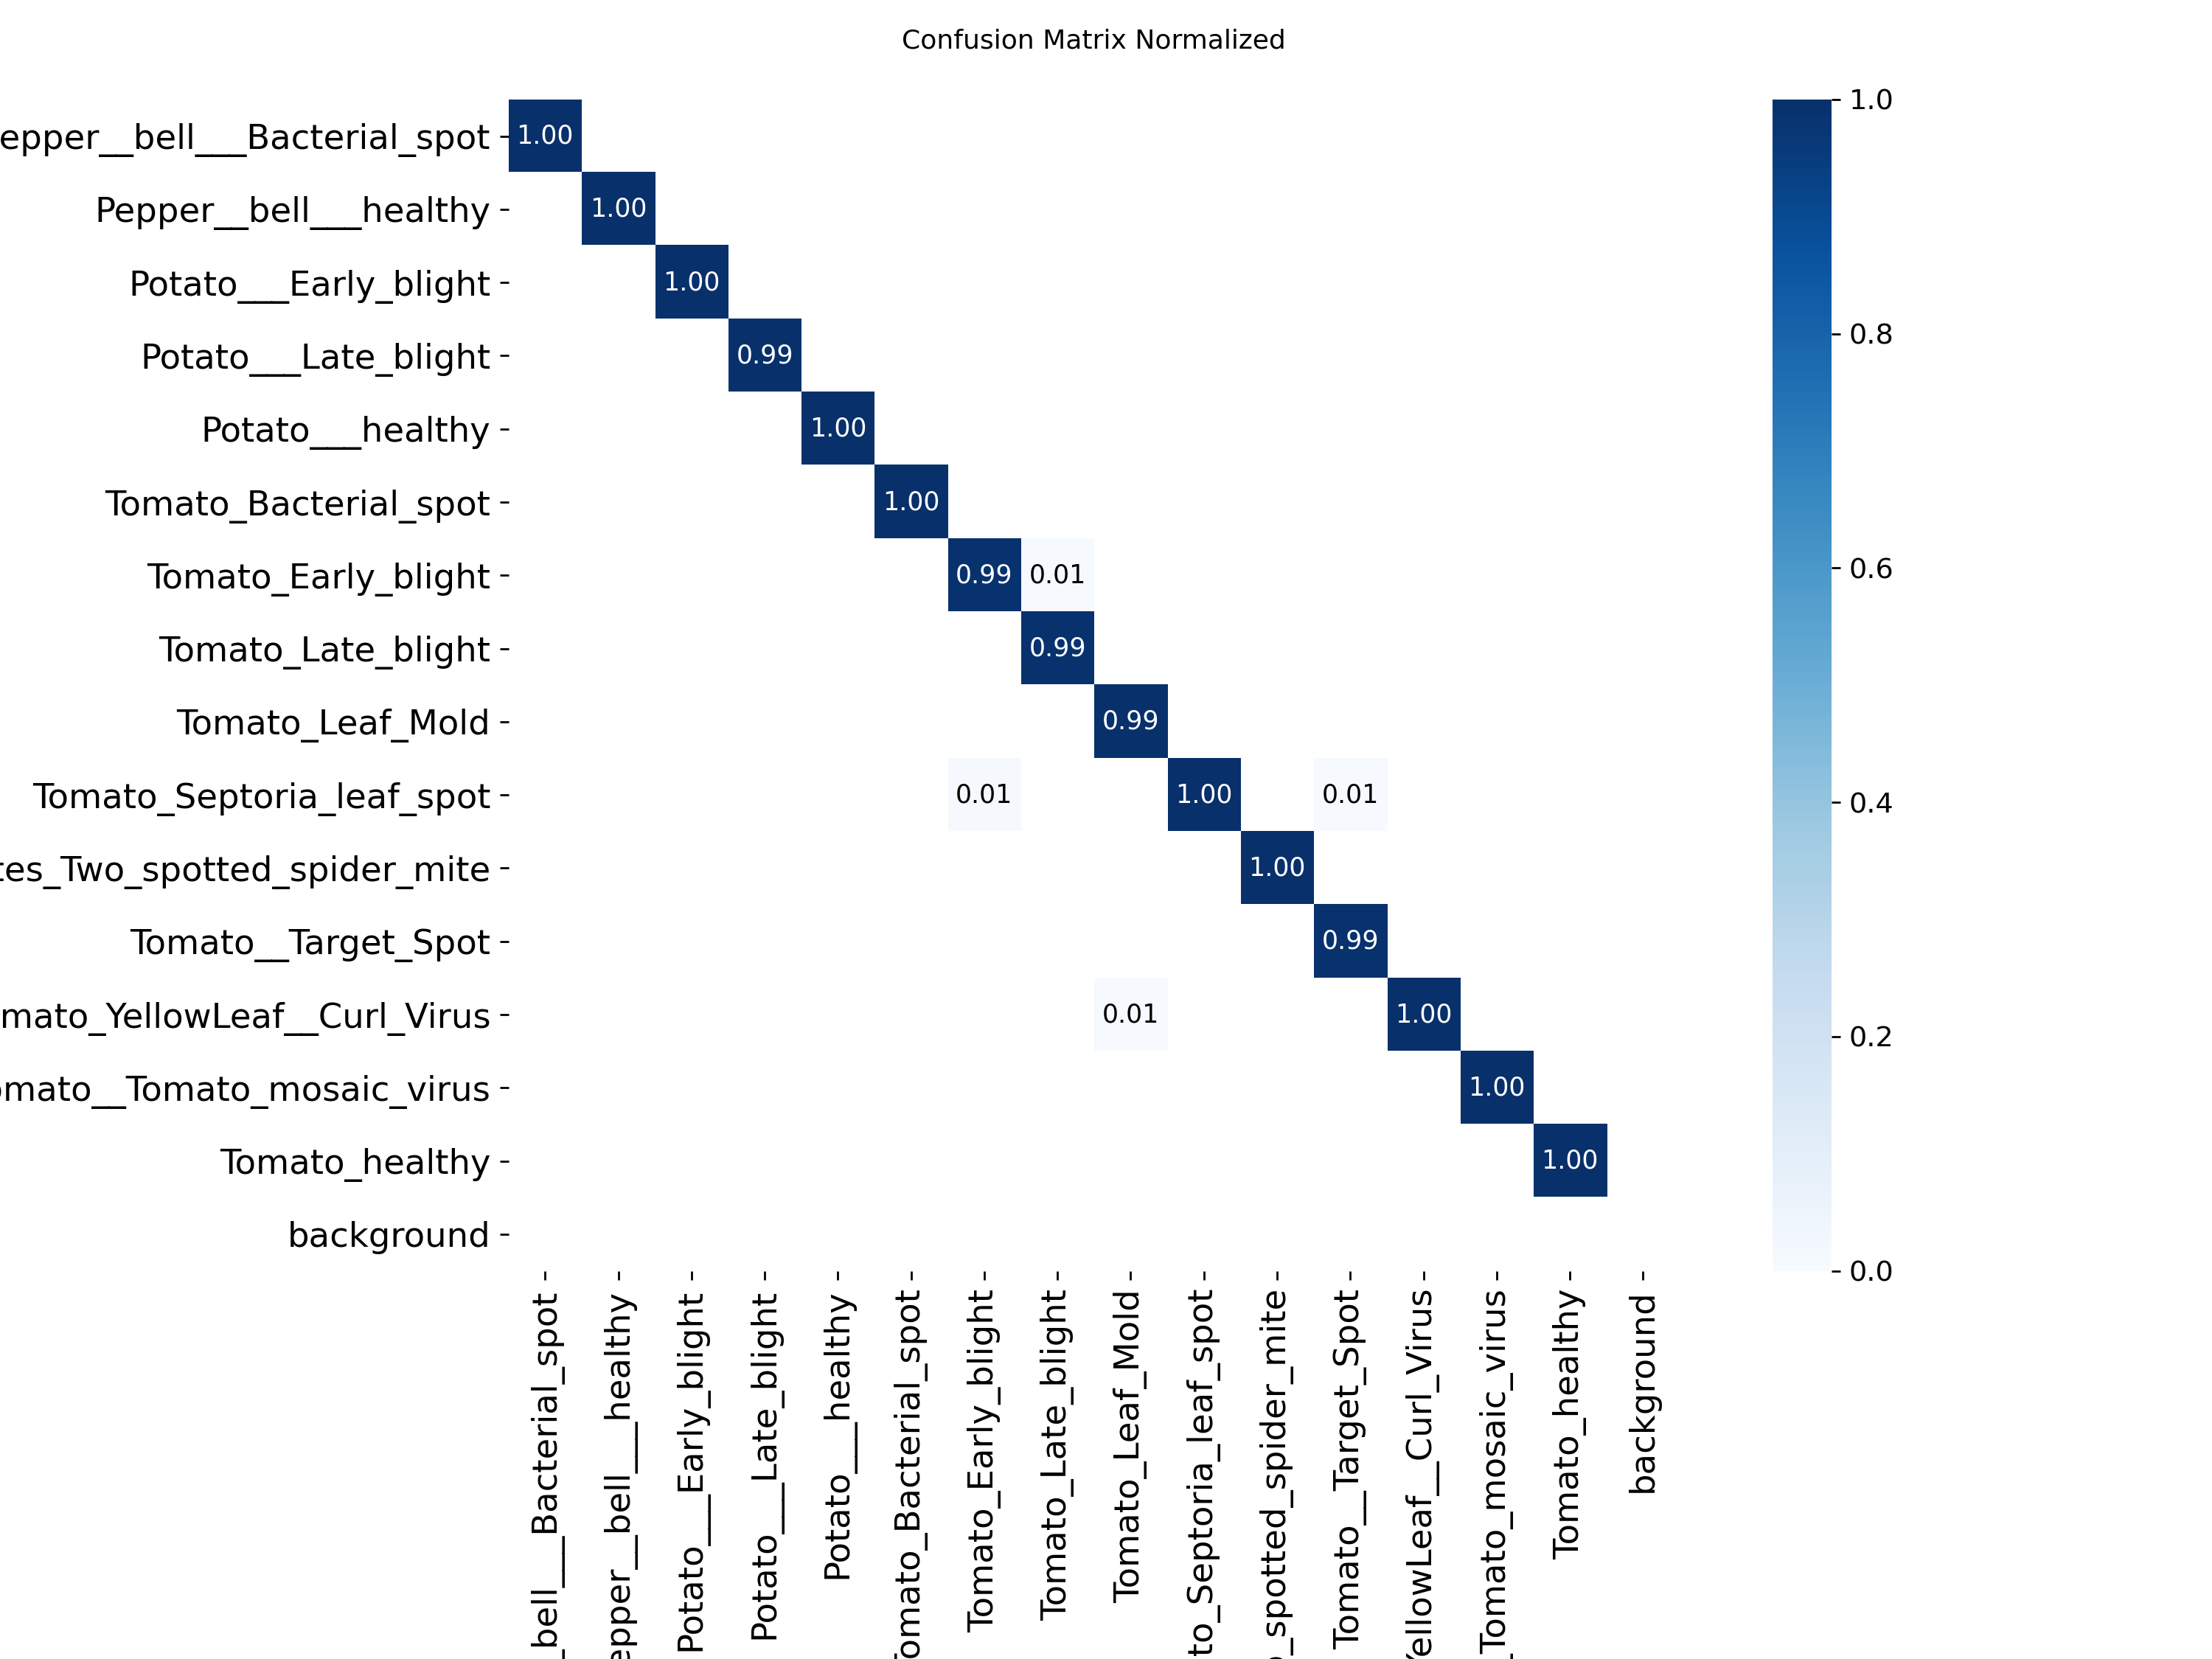


Training Metrics:


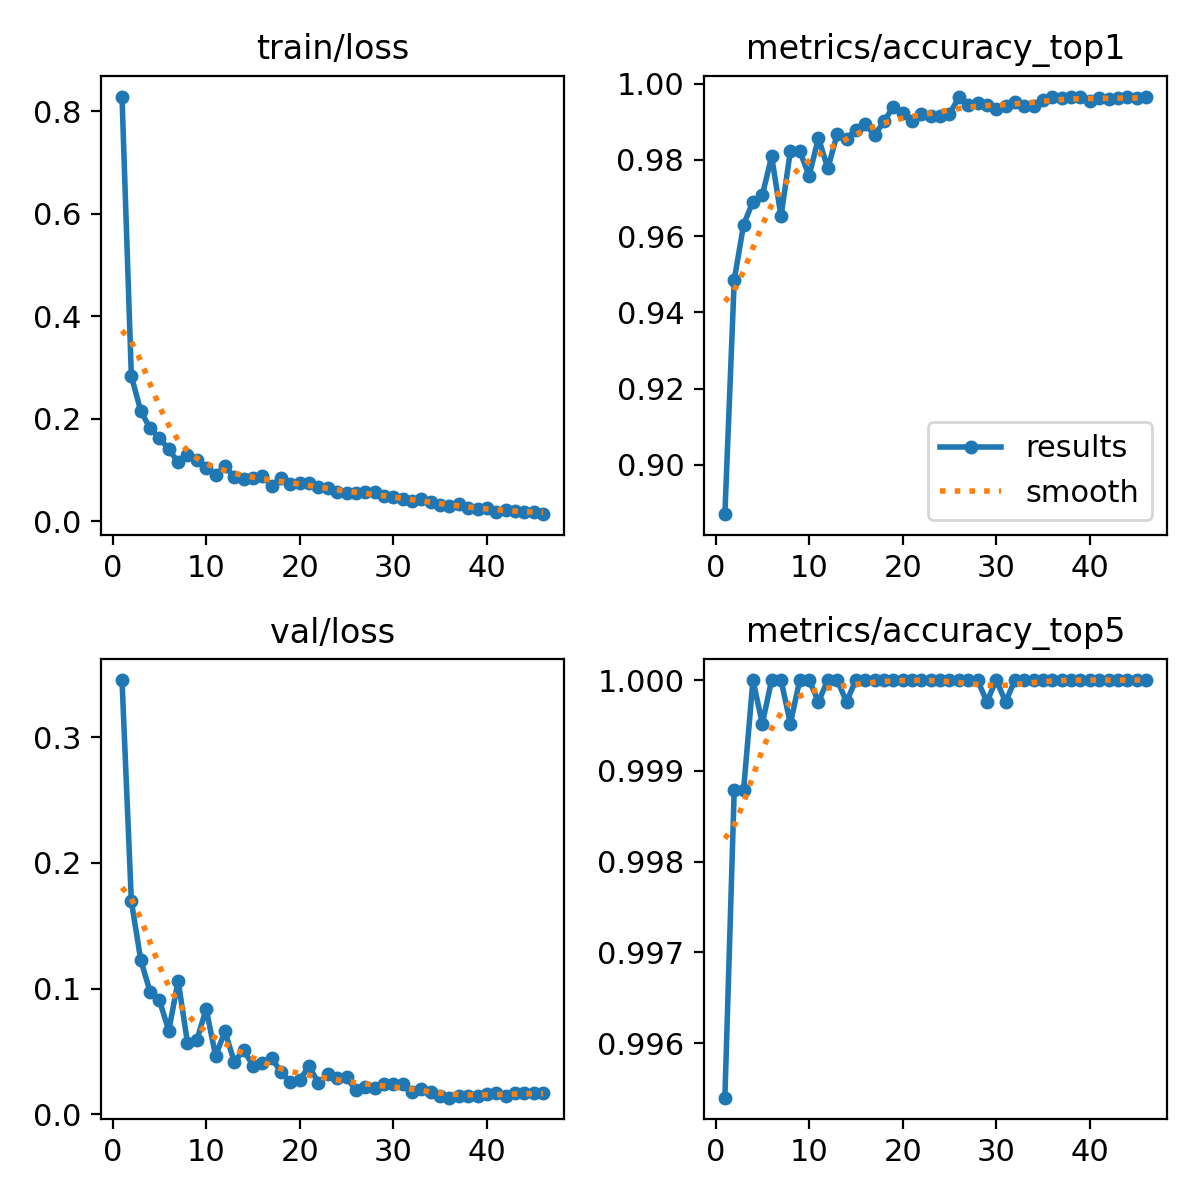

In [6]:
# Display results
from IPython.display import Image, display

results_dir = Path(PROJECT_NAME) / RUN_NAME

print("\nTraining Results:")
print(f"Best weights saved to: {results_dir / 'weights' / 'best.pt'}")
print(f"Last weights saved to: {results_dir / 'weights' / 'last.pt'}")

# Display confusion matrix
if (results_dir / 'confusion_matrix_normalized.png').exists():
    print("\nConfusion Matrix (Normalized):")
    display(Image(filename=str(results_dir / 'confusion_matrix_normalized.png'), width=800))

# Display results
if (results_dir / 'results.png').exists():
    print("\nTraining Metrics:")
    display(Image(filename=str(results_dir / 'results.png'), width=1000))

In [7]:
# Print final metrics
import pandas as pd

csv_path = results_dir / 'results.csv'
if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    print("\nFinal Training Metrics:")
    print("="*60)
    
    last_epoch = df.iloc[-1]
    
    metrics = [
        ('Epoch', 'epoch'),
        ('Train Loss', 'train/loss'),
        ('Validation Loss', 'val/loss'),
        ('Top-1 Accuracy', 'metrics/accuracy_top1'),
        ('Top-5 Accuracy', 'metrics/accuracy_top5')
    ]
    
    for label, col in metrics:
        if col in df.columns:
            value = last_epoch[col]
            if 'accuracy' in col:
                print(f"{label:20s}: {value:.2%}")
            else:
                print(f"{label:20s}: {value:.4f}")
    
    print("="*60)
    
    # Find best epoch
    if 'metrics/accuracy_top1' in df.columns:
        best_idx = df['metrics/accuracy_top1'].idxmax()
        best_epoch = df.iloc[best_idx]
        print(f"\nBest Epoch: {int(best_epoch['epoch'])}")
        print(f"Top-1 Accuracy: {best_epoch['metrics/accuracy_top1']:.2%}")
        if 'metrics/accuracy_top5' in df.columns:
            print(f"Top-5 Accuracy: {best_epoch['metrics/accuracy_top5']:.2%}")


Final Training Metrics:
Epoch               : 46.0000
Train Loss          : 0.0139
Validation Loss     : 0.0166
Top-1 Accuracy      : 99.66%
Top-5 Accuracy      : 100.00%

Best Epoch: 36
Top-1 Accuracy: 99.66%
Top-5 Accuracy: 100.00%


In [ ]:
# Validate the model
print("\nRunning validation on best model...\n")

best_model = YOLO(results_dir / 'weights' / 'best.pt')
val_results = best_model.val(data=str(DATA_DIR))

print("\nValidation complete!")


Testing prediction on sample image...

Test image: 9ef0e7b7-ce38-4829-aad9-23b954a26000___PSU_CG 2324.JPG
True class: Tomato__Tomato_mosaic_virus

Top 5 Predictions:
----------------------------------------------------------------------
1. Tomato__Tomato_mosaic_virus                        100.00%
2. Tomato_Spider_mites_Two_spotted_spider_mite         0.00%
3. Tomato_Leaf_Mold                                    0.00%
4. Tomato_Septoria_leaf_spot                           0.00%
5. Tomato_Early_blight                                 0.00%


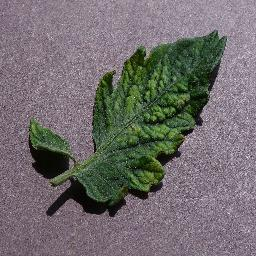

In [9]:
# Test prediction on a sample image
print("\nTesting prediction on sample image...\n")

# Get a random image from one of the classes
import random

test_class = random.choice(classes)
test_images = list((DATA_DIR / test_class).glob('*.jpg')) + list((DATA_DIR / test_class).glob('*.JPG'))
test_image = random.choice(test_images)

print(f"Test image: {test_image.name}")
print(f"True class: {test_class}\n")

# Predict
results = best_model.predict(source=str(test_image), save=False, verbose=False)

# Get top 5 predictions
result = results[0]
probs = result.probs

print("Top 5 Predictions:")
print("-" * 70)
top5_idx = probs.top5
top5_conf = probs.top5conf.tolist()

for i, (idx, conf) in enumerate(zip(top5_idx, top5_conf), 1):
    class_name = classes[idx]
    print(f"{i}. {class_name:50s} {conf:6.2%}")

# Display the image
display(Image(filename=str(test_image), width=400))

## Summary

This notebook trained a YOLOv8 classification model on the PlantVillage dataset without any data augmentation. This serves as the baseline model.

### Key Points:
- 15 classes verified
- No data augmentation applied
- Model saved to `runs/classify/plant_disease_original/weights/best.pt`

### Next Steps:
- Run `train_augmented.ipynb` for training with augmentation
- Compare results between original and augmented models
- Select the best performing model for deployment